# Notebook 1 — Data Generation
Generates synthetic fitness dataset with `fitness_level` as the **only** sensitive attribute.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

os.makedirs('../data', exist_ok=True)
os.makedirs('../results', exist_ok=True)

print('✅ Libraries imported')

✅ Libraries imported


In [6]:
NUM_RECORDS = 7000

REGIONS = ['North', 'South', 'East', 'West']
REGION_WEIGHTS = [0.35, 0.28, 0.22, 0.15]

ACTIVITIES = ['Walking', 'Gym', 'Running', 'Cycling', 'Sports']

print('✅ Parameters defined')

✅ Parameters defined


In [7]:
# Bimodal age distribution
young_count = int(NUM_RECORDS * 0.6)
old_count = NUM_RECORDS - young_count

young_ages = np.random.normal(28, 5, young_count)
old_ages   = np.random.normal(55, 8, old_count)

ages = np.concatenate([young_ages, old_ages])
ages = np.clip(ages, 18, 75).astype(int)
ages = np.random.permutation(ages)

print(f'✅ Ages generated: range {ages.min()}–{ages.max()}, mean {ages.mean():.1f}')

✅ Ages generated: range 18–75, mean 38.2


In [8]:
regions = np.random.choice(REGIONS, size=NUM_RECORDS, p=REGION_WEIGHTS)

activities = []
for age in ages:
    if age < 30:
        act = np.random.choice(ACTIVITIES, p=[0.05, 0.35, 0.30, 0.20, 0.10])
    elif age < 50:
        act = np.random.choice(ACTIVITIES, p=[0.10, 0.30, 0.20, 0.25, 0.15])
    else:
        act = np.random.choice(ACTIVITIES, p=[0.40, 0.25, 0.05, 0.20, 0.10])
    activities.append(act)
activities = np.array(activities)

print('✅ Regions & Activities generated')
print(pd.Series(activities).value_counts())

✅ Regions & Activities generated
Gym        2120
Cycling    1587
Running    1285
Walking    1171
Sports      837
Name: count, dtype: int64


In [9]:
# Steps
base_steps_map = {'Walking': 8000, 'Gym': 10000, 'Running': 15000, 'Cycling': 12000, 'Sports': 13000}
std_steps_map  = {'Walking': 2000, 'Gym': 2500,  'Running': 3000,  'Cycling': 2500,  'Sports': 2500}

steps = []
for age, act in zip(ages, activities):
    age_factor = np.clip(1 - (age - 18) / 150, 0.5, 1.5)
    s = int(np.random.normal(base_steps_map[act] * age_factor, std_steps_map[act]))
    steps.append(max(1000, s))
steps = np.array(steps)

# Calories
act_mult = {'Walking': 0.9, 'Gym': 1.1, 'Running': 1.3, 'Cycling': 1.2, 'Sports': 1.25}
calories = []
for s, act in zip(steps, activities):
    c = int(s * (0.04 + np.random.normal(0, 0.005)) * act_mult[act] * (1 + np.random.normal(0, 0.05)))
    calories.append(max(100, c))
calories = np.array(calories)

# Heart rate
act_hr = {'Walking': 10, 'Gym': 20, 'Running': 40, 'Cycling': 25, 'Sports': 30}
heart_rates = []
for age, act in zip(ages, activities):
    if np.random.random() < 0.05:
        hr = np.random.choice([45, 50, 110, 120, 130])
    else:
        hr = int(np.clip(np.random.normal(60 + (age - 18) * 0.1 + act_hr[act], 8), 40, 150))
    heart_rates.append(hr)
heart_rates = np.array(heart_rates)

# Sleep hours
act_sleep = {'Walking': -0.5, 'Gym': 0.0, 'Running': 0.3, 'Cycling': 0.2, 'Sports': 0.2}
sleep_hours = np.array([round(np.clip(7 + act_sleep[a] + np.random.normal(0, 1), 3, 12), 2) for a in activities])

# Weight
weights = np.array([round(np.clip(70 + (age - 18) * 0.2 + np.random.normal(0, 10), 45, 120), 1) for age in ages])

print(f'✅ Health metrics generated')
print(f'   Steps:    {steps.min()}–{steps.max()}')
print(f'   Calories: {calories.min()}–{calories.max()}')
print(f'   HR:       {heart_rates.min()}–{heart_rates.max()}')

✅ Health metrics generated
   Steps:    1000–22701
   Calories: 100–1445
   HR:       44–130


In [10]:
# ---------------------------------------------------------
# FITNESS LEVEL — the ONLY sensitive attribute
# Deterministic, derived strictly from steps and calories
# ---------------------------------------------------------
def compute_fitness_level(steps, calories):
    if steps >= 12000 and calories >= 600:
        return 'fit'
    elif steps < 7000 and calories < 350:
        return 'unfit'
    else:
        return 'moderately_fit'

fitness_levels = np.array([compute_fitness_level(s, c) for s, c in zip(steps, calories)])

print('✅ fitness_level computed (no randomness)')
print(pd.Series(fitness_levels).value_counts())

✅ fitness_level computed (no randomness)
moderately_fit    4039
unfit             1488
fit               1473
Name: count, dtype: int64


In [11]:
# Step & calorie range bins (treated as normal attributes, NOT sensitive)
step_bins    = [0, 5000, 8000, 11000, 14000, 25000]
step_labels  = ['<5k', '5k-8k', '8k-11k', '11k-14k', '>14k']
cal_bins     = [0, 250, 400, 550, 700, 3000]
cal_labels   = ['<250', '250-400', '400-550', '550-700', '>700']

step_range    = pd.cut(steps,    bins=step_bins,  labels=step_labels,  include_lowest=True)
calories_range = pd.cut(calories, bins=cal_bins,   labels=cal_labels,   include_lowest=True)

df = pd.DataFrame({
    'age':            ages,
    'region':         regions,
    'activity':       activities,
    'heart_rate':     heart_rates,
    'steps':          steps,
    'calories':       calories,
    'step_range':     step_range,
    'calories_range': calories_range,
    'sleep_hours':    sleep_hours,
    'weight_kg':      weights,
    'fitness_level':  fitness_levels   # ONLY sensitive attribute
})

print(f'✅ DataFrame built — shape: {df.shape}')
print(f'   Columns: {list(df.columns)}')
print(df.head())

✅ DataFrame built — shape: (7000, 11)
   Columns: ['age', 'region', 'activity', 'heart_rate', 'steps', 'calories', 'step_range', 'calories_range', 'sleep_hours', 'weight_kg', 'fitness_level']
   age region activity  heart_rate  steps  calories step_range calories_range  \
0   22   East      Gym          85  10170       433     8k-11k        400-550   
1   20  South  Running         105  11890       545    11k-14k        400-550   
2   50  North      Gym          62   6461       270      5k-8k        250-400   
3   29  North      Gym          77  12858       687    11k-14k        550-700   
4   31  North  Walking          68  11024       486    11k-14k        400-550   

   sleep_hours  weight_kg   fitness_level  
0         5.81       76.0  moderately_fit  
1         5.94       79.1  moderately_fit  
2         7.19       71.1           unfit  
3         8.29       67.2             fit  
4         8.96       82.7  moderately_fit  


In [12]:
df.to_csv('../data/raw_fitness_data.csv', index=False)
print('✅ Saved: ../data/raw_fitness_data.csv')

print('\n--- fitness_level distribution (sensitive attribute) ---')
print(df['fitness_level'].value_counts())
print(df['fitness_level'].value_counts(normalize=True).round(3))

✅ Saved: ../data/raw_fitness_data.csv

--- fitness_level distribution (sensitive attribute) ---
fitness_level
moderately_fit    4039
unfit             1488
fit               1473
Name: count, dtype: int64
fitness_level
moderately_fit    0.577
unfit             0.213
fit               0.210
Name: proportion, dtype: float64


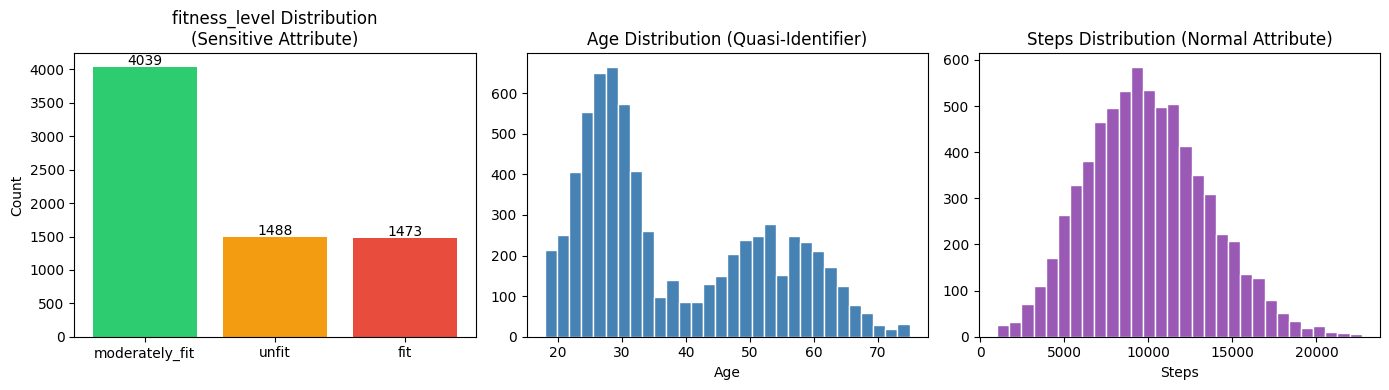

✅ Visualization saved


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# fitness_level distribution
counts = df['fitness_level'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_title('fitness_level Distribution\n(Sensitive Attribute)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=10)

# Age distribution
axes[1].hist(df['age'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Age Distribution (Quasi-Identifier)')
axes[1].set_xlabel('Age')

# Steps distribution
axes[2].hist(df['steps'], bins=30, color='#9b59b6', edgecolor='white')
axes[2].set_title('Steps Distribution (Normal Attribute)')
axes[2].set_xlabel('Steps')

plt.tight_layout()
plt.savefig('../results/01_data_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Visualization saved')